In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
import io
import datetime as dt
import matplotlib.ticker as tck

In [2]:
LOG_DIR = Path('/g/data/gb02/public/dashboard/pag548')

Load the default case with no I/O server

In [3]:
def read_hpc_log(file):
   # Read line by line if dealing with JSON lines
    with open(file, 'r') as file:
        data = [json.loads(line) for line in file] 

    df = pd.json_normalize(data)
    
    df['time'] = pd.to_datetime(df.t, unit = 's')  #Convert linux epoch time into a datetime object
    df['time_elapsed'] = df['time'] - df['time'].iloc[0]
    df['seconds'] = df['time_elapsed'].dt.total_seconds()  # Required for sensible plotting
    df.set_index('time_elapsed',inplace=True)
    df.sort_index(inplace=True)  #Make sure you do this otherwise location indexing will fail!
    df['rss_bytes_sum'] = df['rss_bytes_sum']/1e9 #Convert to Gb
    df['io_read_bytes'] = df['io_read_bytes']/1e9 #Convert to Gb
    df['io_write_bytes'] = df['io_write_bytes']/1e9 #Convert to Gb

    return df

In [4]:
default_log = LOG_DIR / 'AM3_N512_no_ioserver_repeat.log'
baseline = read_hpc_log(default_log)

In [5]:
baseline[['seconds','rss_bytes_sum','system_cpu_efficiency']]

,seconds,rss_bytes_sum,system_cpu_efficiency
time_elapsed,,,
0 days 00:00:00,0.000,NaN,NaN
0 days 00:00:00.553999901,0.554,0.017953,76.880901
0 days 00:00:01.104999781,1.105,0.027300,68.391689
0 days 00:00:01.659999848,1.660,0.028180,112.877606
0 days 00:00:02.214999914,2.215,0.035254,116.060488
...,...,...,...
0 days 00:39:40.271999836,2380.272,0.039625,0.489024
0 days 00:39:40.822999954,2380.823,0.044954,22.800451
0 days 00:39:41.373999834,2381.374,0.039629,0.713255


Load the corresponding pe_output file

In [6]:
PE_DIR = Path('/g/data/gb02/pag548/sapphire_logs/AM3-optimisation/work/atmos_main/')
default_pe = PE_DIR / 'AM3_no_io_server/acces.fort6.pe0000'

In [7]:
def read_pe(file):
    csv_start = io.StringIO()
    csv_start_lines = []
    
    with open(file, 'r') as fp:
        for index,line in enumerate(fp):
            if 'Atm_Step: Info: Starting' in line:
                csv_start_lines.append(f'{line}')
    
    for line in csv_start_lines:
        csv_start.write(line)
    
    csv_start.seek(0)
    df = pd.read_csv(csv_start, header=None,sep='\s+')
    df.rename(columns = {4:'timestep',7:'seconds'},inplace=True)
    df.loc[:,'marker'] = 1.0
    df['time'] = pd.to_datetime(df.seconds, unit = 's')
    df['time_elapsed'] = df['time'] - pd.to_datetime(0.0, unit = 's')
    df.set_index('time_elapsed',inplace=True)

    return df

In [8]:
default_timesteps = read_pe(default_pe)

In [9]:
default_timesteps[['seconds','timestep']]

,seconds,timestep
time_elapsed,,
0 days 00:01:24.339000,84.339,0
0 days 00:01:32.927000,92.927,1
0 days 00:01:38.033000,98.033,2
0 days 00:01:39.472000,99.472,3
0 days 00:01:40.928000,100.928,4
...,...,...
0 days 00:36:07.895000,2167.895,860
0 days 00:36:09.216000,2169.216,861
0 days 00:36:10.552000,2170.552,862


Confirm this matches the raw pe output

```
Atm_Step: Info: Starting timestep        0 at time=    84.339 seconds

Atm_Step: Timestep        0   Model time:   2007-01-01 00:00:00
``
and
``
model running with timestep     600.00 seconds
Atm_Step: Info: Starting timestep        1 at time=    92.927 seconds

Atm_Step: Timestep        1   Model time:   2007-01-01 00:10:00
EG_SISL_Resetcon: calculate reference profile
Initialising coarse grids...
Number of multigrid level requested         :     3
Number of multigrid level allowed (lon/lat) : (   5 /    5 )
Level     1:   1024 x    768 x   85 =       66846720
Level     2:    512 x    504 x   85 =       21934080
Level     3:    256 x    310 x   85 =        6745600
grid complexity =   1.4290 [ lower bound =   1.3125 ]
...Done
```
and
```
Atm_Step: Info: Starting timestep        2 at time=    98.033 seconds

Atm_Step: Timestep        2   Model time:   2007-01-01 00:20:00
EG_SISL_Resetcon: calculate reference profile
```

In [10]:
from matplotlib.ticker import FuncFormatter

# 1. The formatter now expects 'x' to be plain seconds (float)
def format_seconds_to_hms(x, pos):
    hours, remainder = divmod(x, 3600)
    minutes, seconds = divmod(remainder, 60)
    # Handles sub-second precision accurately
    return f"{int(hours):02d}:{int(minutes):02d}:{seconds:06.3f}"

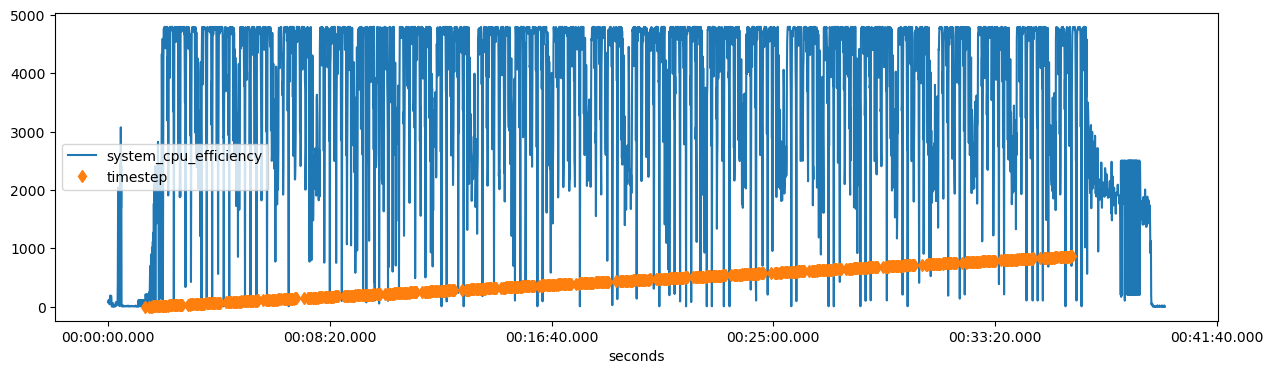

In [11]:
fig,ax = plt.subplots(figsize=(15,4))
baseline.set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax)
default_timesteps.set_index('seconds')[['timestep']].plot(ax=ax,marker='d',linewidth=0)
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))


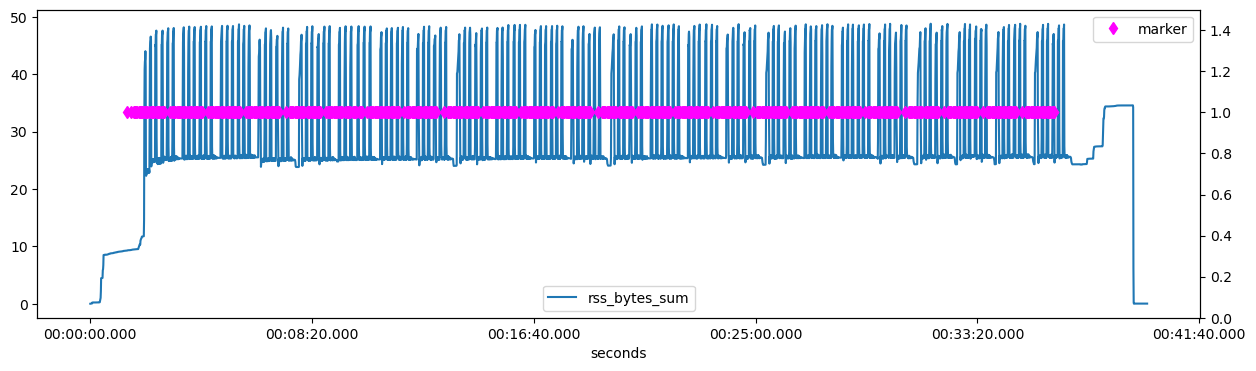

In [12]:
fig,ax = plt.subplots(figsize=(15,4))
ax2 = ax.twinx()
baseline.set_index('seconds')[['rss_bytes_sum']].plot(ax=ax)
default_timesteps.set_index('seconds')[['marker']].plot(ax=ax2,marker='d',linewidth=0,color='magenta')
# Define formatter function for minutes and seconds
ax2.set_ylim([0,1.5])
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))

OK according to the standard output 

```
Atm_Step: Info: Starting timestep        1 at time=    92.927 seconds

Atm_Step: Info: Starting timestep        2 at time=    98.033 seconds

Atm_Step: Info: Starting timestep        3 at time=    99.472 seconds
```

Let's examine the logs at this point

<Axes: xlabel='seconds'>

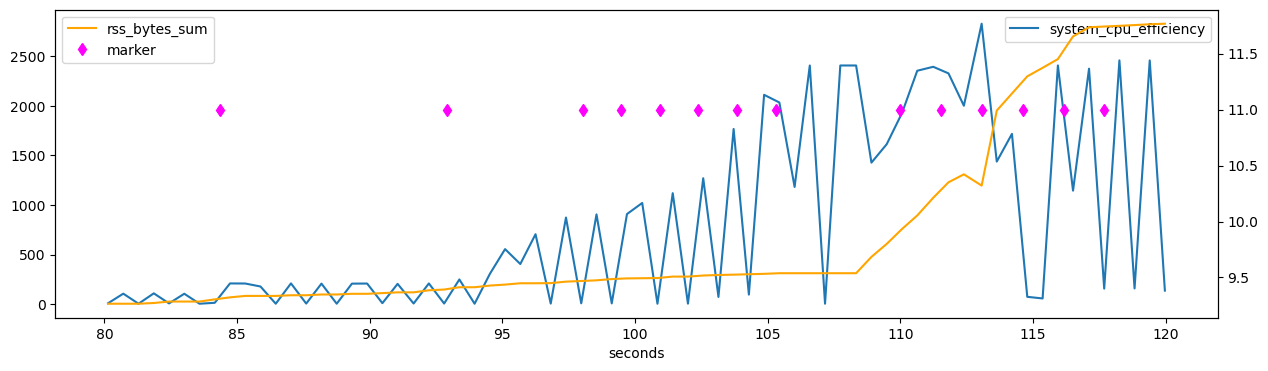

In [13]:
fig,ax = plt.subplots(figsize=(15,4))
start = pd.Timedelta('80 seconds')
end =  pd.Timedelta('120 seconds')
baseline.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax)
ax2 = ax.twinx()
baseline.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax2,color='orange')
(default_timesteps.loc[start:end].set_index('seconds')[['marker']]+10).plot(ax=ax2,marker='d',linewidth=0,color='magenta')

Let's track the next few iterations

In [14]:
default_timesteps.loc[start:end].set_index('seconds')[['timestep','marker']]

,timestep,marker
seconds,,
84.339,0,1.0
92.927,1,1.0
98.033,2,1.0
99.472,3,1.0
100.928,4,1.0
102.392,5,1.0
103.843,6,1.0
105.300,7,1.0
109.996,8,1.0


<Axes: xlabel='seconds'>

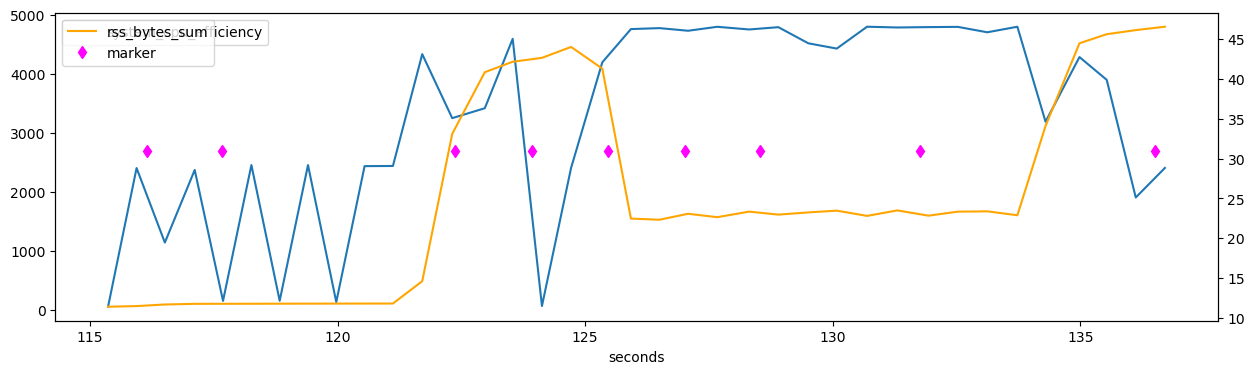

In [15]:
fig,ax = plt.subplots(figsize=(15,4))
start = pd.Timedelta('115 seconds')
end =  pd.Timedelta('137 seconds')
baseline.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax)
ax2 = ax.twinx()
baseline.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax2,color='orange')
(default_timesteps.loc[start:end].set_index('seconds')[['marker']]+30).plot(ax=ax2,marker='d',linewidth=0,color='magenta')

Let's try and overlay some disk I/O

<Axes: xlabel='seconds'>

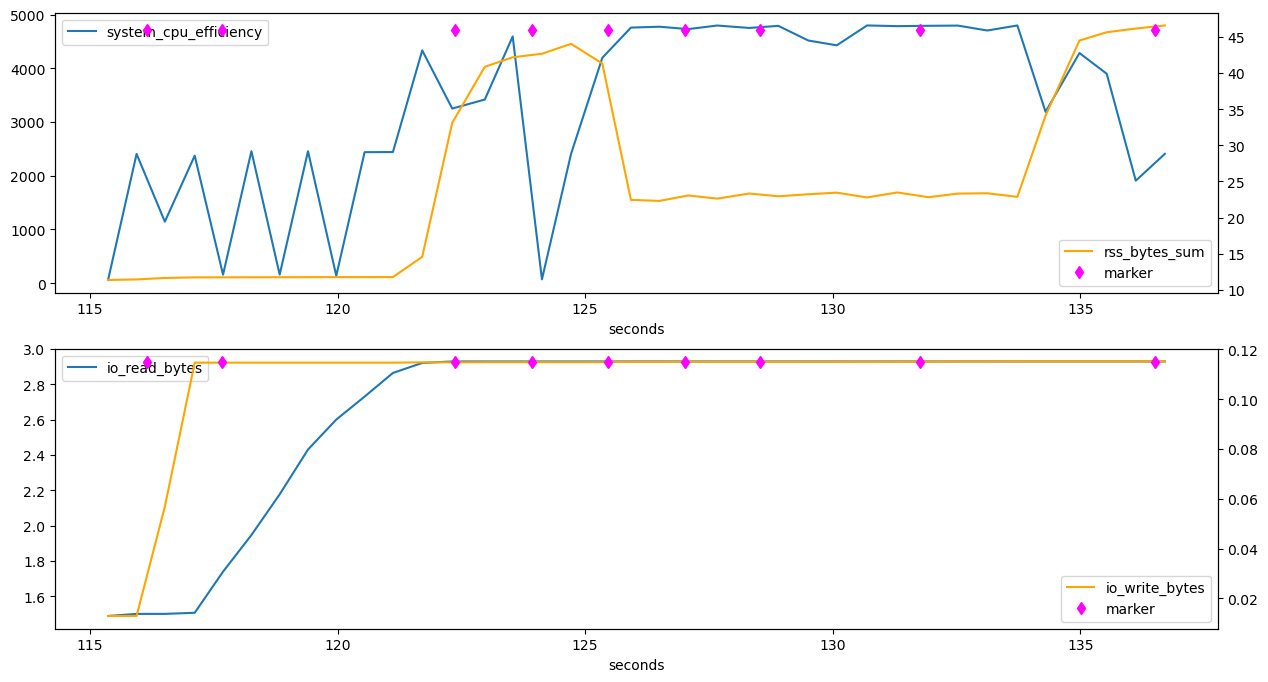

In [16]:
fig,ax = plt.subplots(2,1,figsize=(15,8))
baseline.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax[0])
ax2 = ax[0].twinx()
baseline.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax2,color='orange')
(default_timesteps.loc[start:end].set_index('seconds')[['marker']]+45).plot(ax=ax2,marker='d',linewidth=0,color='magenta')

baseline.loc[start:end].set_index('seconds')[['io_read_bytes']].plot(ax=ax[1])
ax3 = ax[1].twinx()
baseline.loc[start:end].set_index('seconds')[['io_write_bytes']].plot(ax=ax3,color='orange').legend(loc='lower left')
(default_timesteps.loc[start:end].set_index('seconds')[['marker']]/8.7).plot(ax=ax3,marker='d',linewidth=0,color='magenta')
                                                                                                     

Expand for a longer window. Add network traffic

<Axes: xlabel='seconds'>

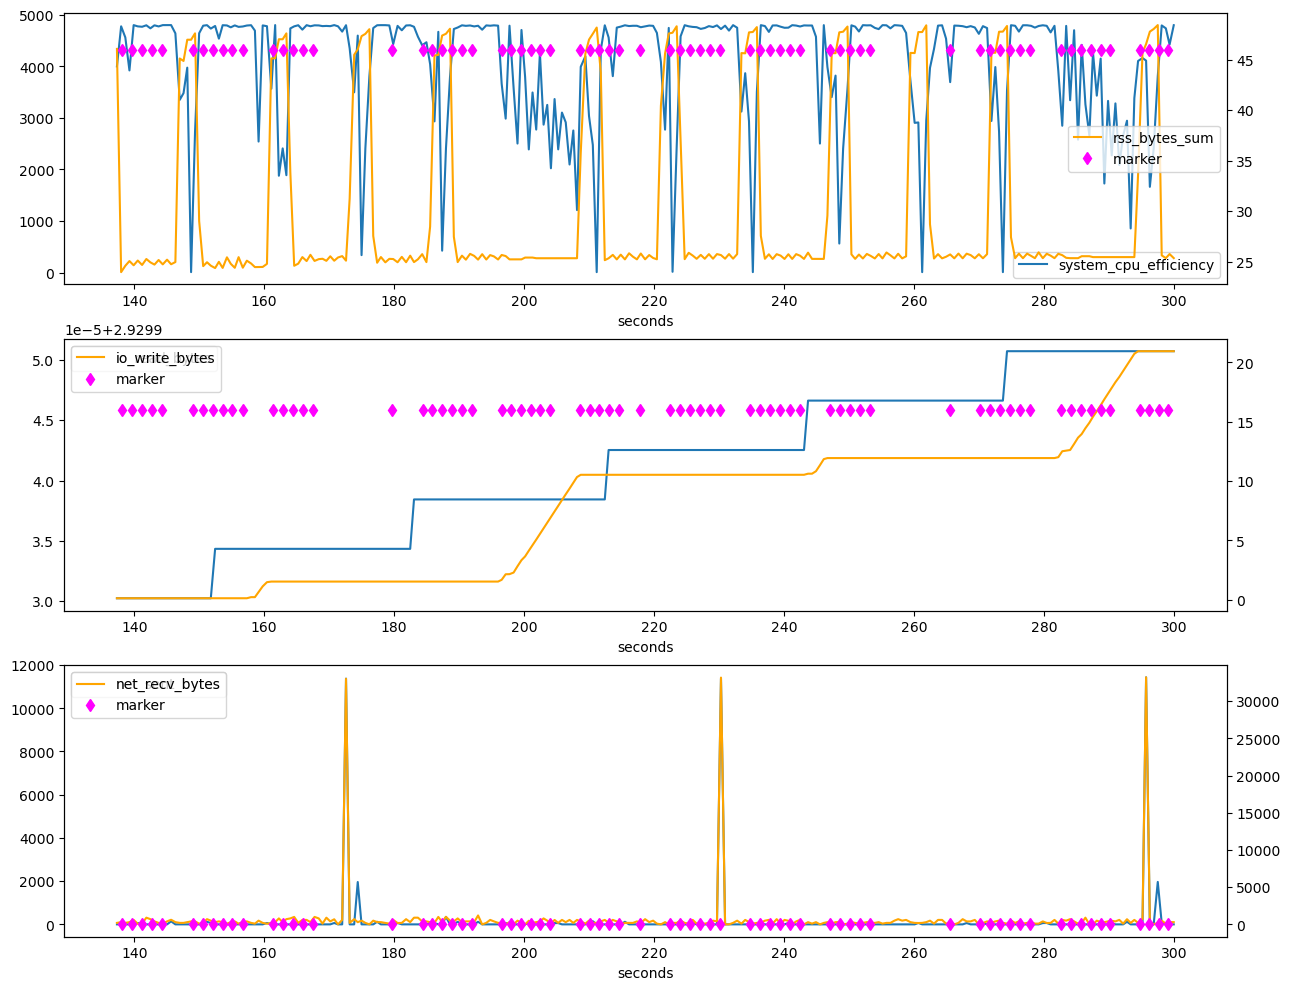

In [17]:
fig,ax = plt.subplots(3,1,figsize=(15,12))
start = pd.Timedelta('137 seconds')
end =  pd.Timedelta('300 seconds')
baseline.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax[0])
ax2 = ax[0].twinx()
baseline.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax2,color='orange')
(default_timesteps.loc[start:end].set_index('seconds')[['marker']]+45).plot(ax=ax2,marker='d',linewidth=0,color='magenta')

baseline.loc[start:end].set_index('seconds')[['io_read_bytes']].plot(ax=ax[1])
ax3 = ax[1].twinx()
baseline.loc[start:end].set_index('seconds')[['io_write_bytes']].plot(ax=ax3,color='orange').legend(loc='lower right')
(default_timesteps.loc[start:end].set_index('seconds')[['marker']]+15).plot(ax=ax3,marker='d',linewidth=0,color='magenta')

baseline.loc[start:end].set_index('seconds')[['net_sent_bytes']].plot(ax=ax[2])
ax4 = ax[2].twinx()
baseline.loc[start:end].set_index('seconds')[['net_recv_bytes']].plot(ax=ax4,color='orange').legend(loc='upper left')
(default_timesteps.loc[start:end].set_index('seconds')[['marker']]).plot(ax=ax4,marker='d',linewidth=0,color='magenta')


This implies the `io_<read|write>_bytes` fields are cumulative? Let's check.

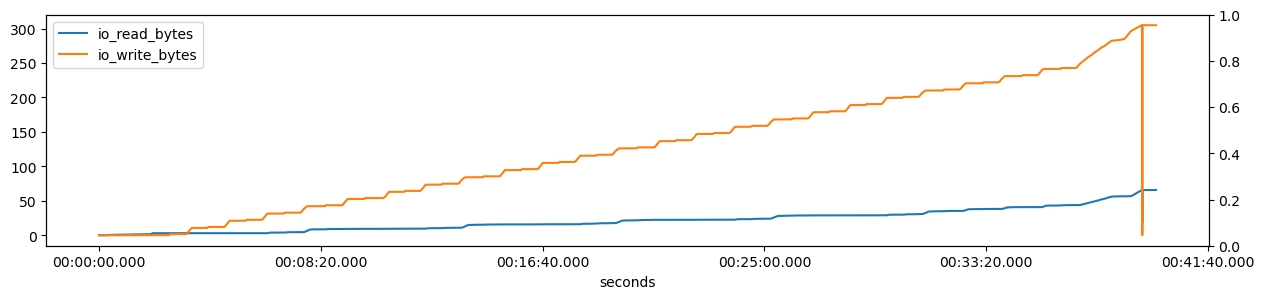

In [18]:
fig,ax = plt.subplots(figsize=(15,3))
baseline.set_index('seconds')[['io_read_bytes']].plot(ax=ax)
ax2 = ax.twinx()
baseline.set_index('seconds')[['io_write_bytes']].plot(ax=ax)
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))

In [19]:
baseline.columns

Index(['allowed_cpus', 'booked_mem', 'booked_walltime', 'cpus_per_task',
       'event', 'job_id', 'job_name', 'num_nodes', 'project', 'queue', 't',
       'tasks_per_node', 'user_id', 'cpu_pct_sum', 'rss_bytes_sum', 'n_procs',
       'system_percpu_pct', 'tree_percpu_pct', 'system_cpu_efficiency',
       'n_threads', 'n_open_fds', 'major_faults', 'minor_faults',
       'io_read_bytes', 'io_write_bytes', 'io_read_ops', 'io_write_ops',
       'swap_bytes', 'net_recv_bytes', 'net_sent_bytes', 'net_recv_packets',
       'net_sent_packets', 'gpu_utilization', 'gpu_memory_used',
       'gpu_memory_total', 'gpu_temperature', 'gpu_power', 'time', 'seconds'],
      dtype='object')

Now compare to logs with I/O server and Sapphire Rapids optimisation

In [20]:
io_log = LOG_DIR / 'AM3_N512_default.log'
sapphire_log = LOG_DIR / 'AM3_N512_SapphireRapids.log'

In [29]:
io_df = read_hpc_log(io_log)
sr_df = read_hpc_log(sapphire_log)

In [64]:
io_pe = PE_DIR / 'AM3_default/acces.fort6.pe0000'
io_timesteps = read_pe(io_pe)

sph_pe = PE_DIR / 'AM3_sapphire/acces.fort6.pe0000'
sr_timesteps = read_pe(sph_pe)

First assess the impact of the I/O server

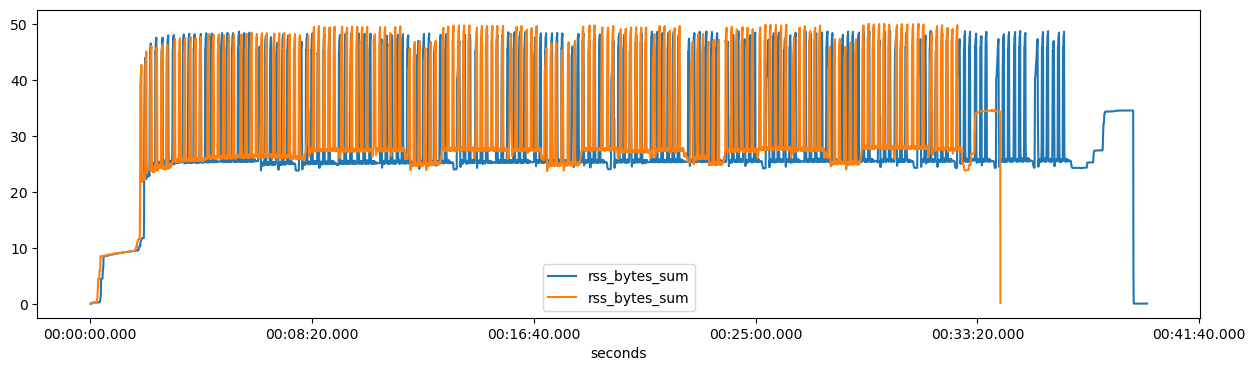

In [59]:
fig,ax = plt.subplots(figsize=(15,4))
baseline.set_index('seconds')[['rss_bytes_sum']].plot(ax=ax,label='Default')
io_df.set_index('seconds')[['rss_bytes_sum']].plot(ax=ax,label='I/O server')
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))
ax.legend()

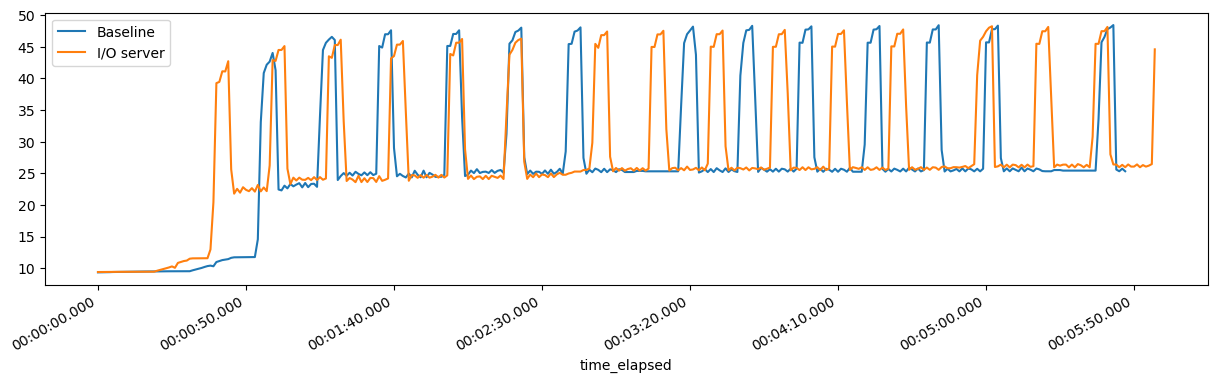

In [60]:
fig,ax = plt.subplots(figsize=(15,4))
start = pd.Timedelta('90 seconds')
end =  pd.Timedelta('300 seconds')
baseline[start:end][['rss_bytes_sum']].plot(ax=ax)
io_df[start:end][['rss_bytes_sum']].plot(ax=ax)
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))
lines, labels = ax.get_legend_handles_labels()
labels=['Baseline','I/O server']
ax.legend(lines,labels)

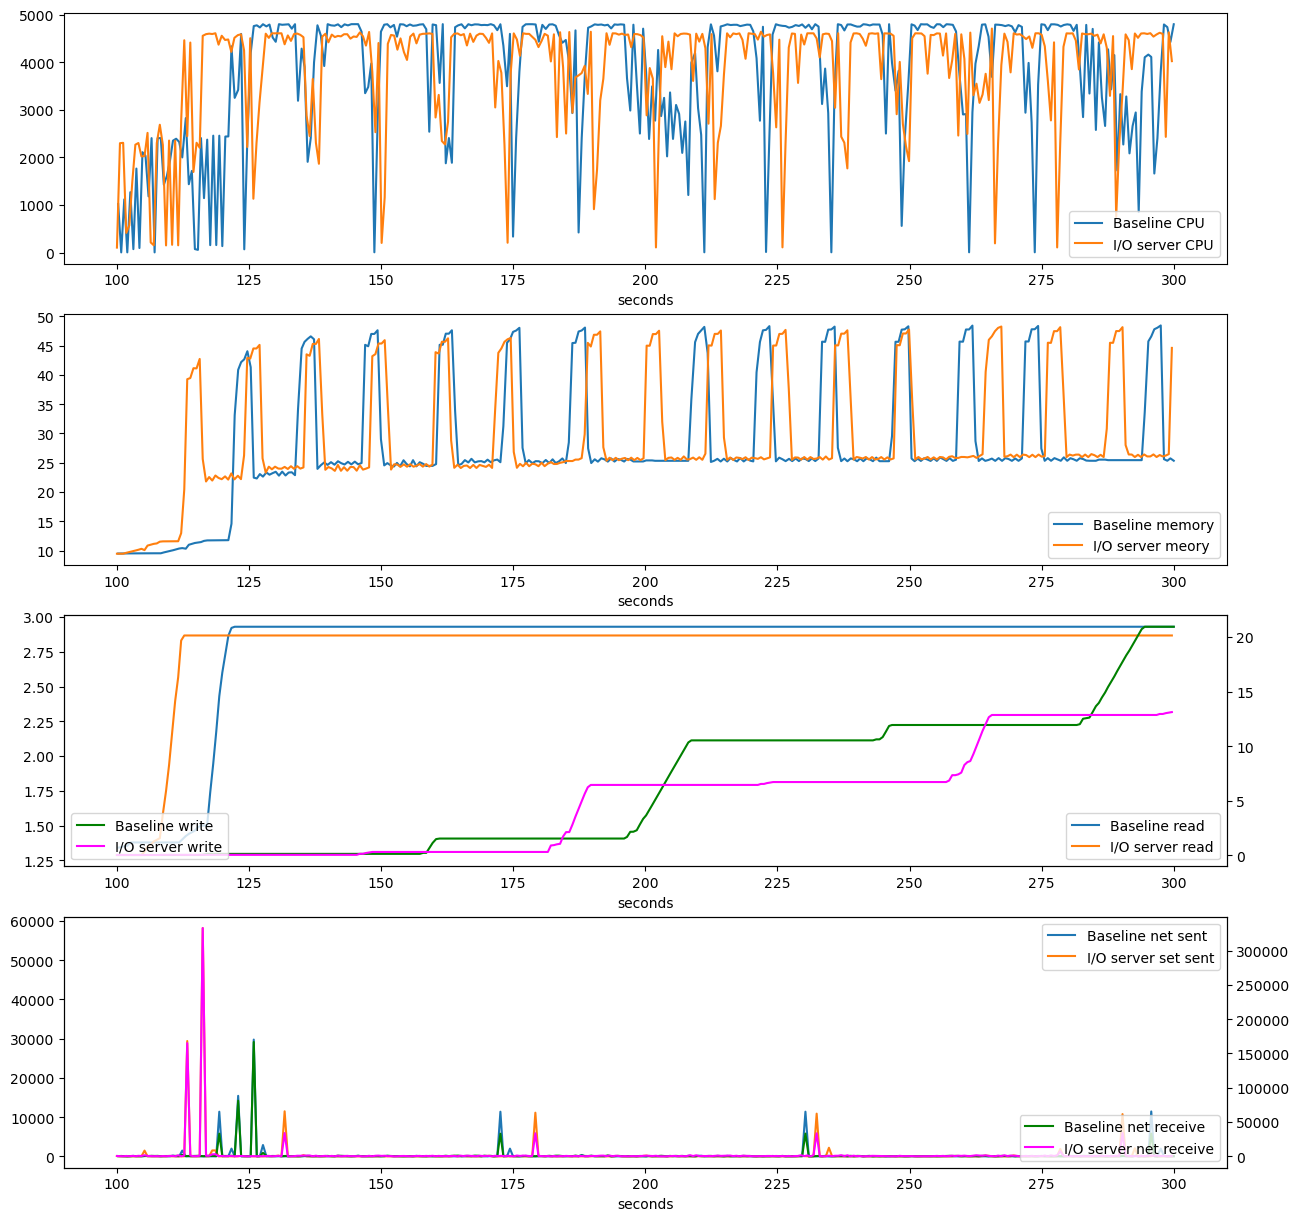

In [25]:
fig,ax = plt.subplots(4,1,figsize=(15,15))
start = pd.Timedelta('100 seconds')
end =  pd.Timedelta('300 seconds')
baseline.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax[0])
io_df.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax[0])
lines, labels = ax[0].get_legend_handles_labels()
labels=['Baseline CPU','I/O server CPU']
ax[0].legend(lines,labels)

baseline.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax[1])
io_df.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax[1])
lines, labels = ax[1].get_legend_handles_labels()
labels=['Baseline memory','I/O server meory']
ax[1].legend(lines,labels)

baseline.loc[start:end].set_index('seconds')[['io_read_bytes']].plot(ax=ax[2])
io_df.loc[start:end].set_index('seconds')[['io_read_bytes']].plot(ax=ax[2])
lines, labels = ax[2].get_legend_handles_labels()
labels=['Baseline read','I/O server read']
ax[2].legend(lines,labels)

ax3 = ax[2].twinx()
baseline.loc[start:end].set_index('seconds')[['io_write_bytes']].plot(ax=ax3,color='green').legend(loc='lower right')
io_df.loc[start:end].set_index('seconds')[['io_write_bytes']].plot(ax=ax3,color='magenta').legend(loc='lower right')
lines, labels = ax3.get_legend_handles_labels()
labels=['Baseline write','I/O server write']
ax3.legend(lines,labels,loc='lower left')

baseline.loc[start:end].set_index('seconds')[['net_sent_bytes']].plot(ax=ax[3])
io_df.loc[start:end].set_index('seconds')[['net_sent_bytes']].plot(ax=ax[3])
lines, labels = ax[3].get_legend_handles_labels()
labels=['Baseline net sent','I/O server set sent']
ax[3].legend(lines,labels)

ax4 = ax[3].twinx()
baseline.loc[start:end].set_index('seconds')[['net_recv_bytes']].plot(ax=ax4,color='green').legend(loc='upper left')
io_df.loc[start:end].set_index('seconds')[['net_recv_bytes']].plot(ax=ax4,color='magenta').legend(loc='upper left')
lines, labels = ax4.get_legend_handles_labels()
labels=['Baseline net receive','I/O server net receive']
ax4.legend(lines,labels,loc='lower right')

Comparions of pe_output in `xxdiff` for AM3 task with I/O server (left) and without (right)

<img src="images/xxdiff_IO.png">

Repeat for Sapphire rapids run.

There is a glitch in the SR log for memory?

In [49]:
start = pd.Timedelta('200 seconds')
end =  pd.Timedelta('300 seconds')
sr_df.loc[start:end].rss_bytes_sum

time_elapsed
0 days 00:03:20.515000105    0.231313
0 days 00:03:21.114000082    0.231313
0 days 00:03:21.713000059    0.231313
0 days 00:03:22.312000036    0.231313
0 days 00:03:22.904000044    0.231313
                               ...   
0 days 00:04:57.173000097    0.231313
0 days 00:04:57.772000074    0.231313
0 days 00:04:58.370000124    0.231313
0 days 00:04:58.970000028    0.231313
0 days 00:04:59.569999933    0.231313
Name: rss_bytes_sum, Length: 166, dtype: float64

<Axes: xlabel='seconds'>

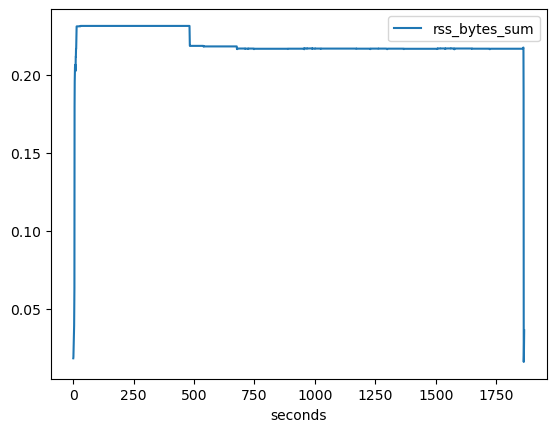

In [55]:
sr_df.set_index('seconds')[['rss_bytes_sum']].plot()

In [50]:
start = pd.Timedelta('200 seconds')
end =  pd.Timedelta('300 seconds')
io_df.loc[start:end].rss_bytes_sum

time_elapsed
0 days 00:03:20.260999918    44.985872
0 days 00:03:20.845000029    44.973421
0 days 00:03:21.432999849    46.962295
0 days 00:03:22.024999857    46.962295
0 days 00:03:22.615999937    47.536759
                               ...    
0 days 00:04:57.338000059    26.311905
0 days 00:04:57.921999931    26.068390
0 days 00:04:58.490000010    26.224685
0 days 00:04:59.054999828    26.469167
0 days 00:04:59.638999939    44.601614
Name: rss_bytes_sum, Length: 171, dtype: float64

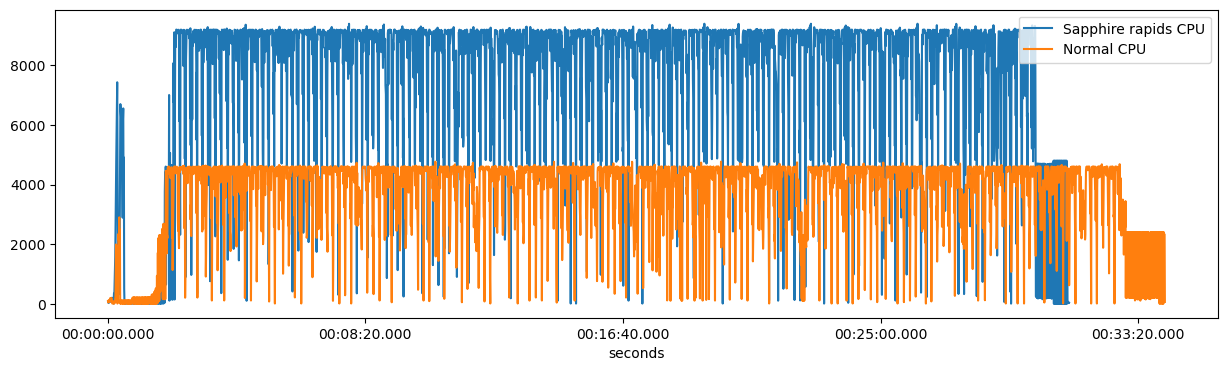

In [47]:
fig,ax = plt.subplots(figsize=(15,4))
sr_df.set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax,label='Sapphire Rapids')
io_df.set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax,label='Default')
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))
lines, labels = ax.get_legend_handles_labels()
labels=['Sapphire rapids CPU','Normal CPU']
ax.legend(lines,labels)

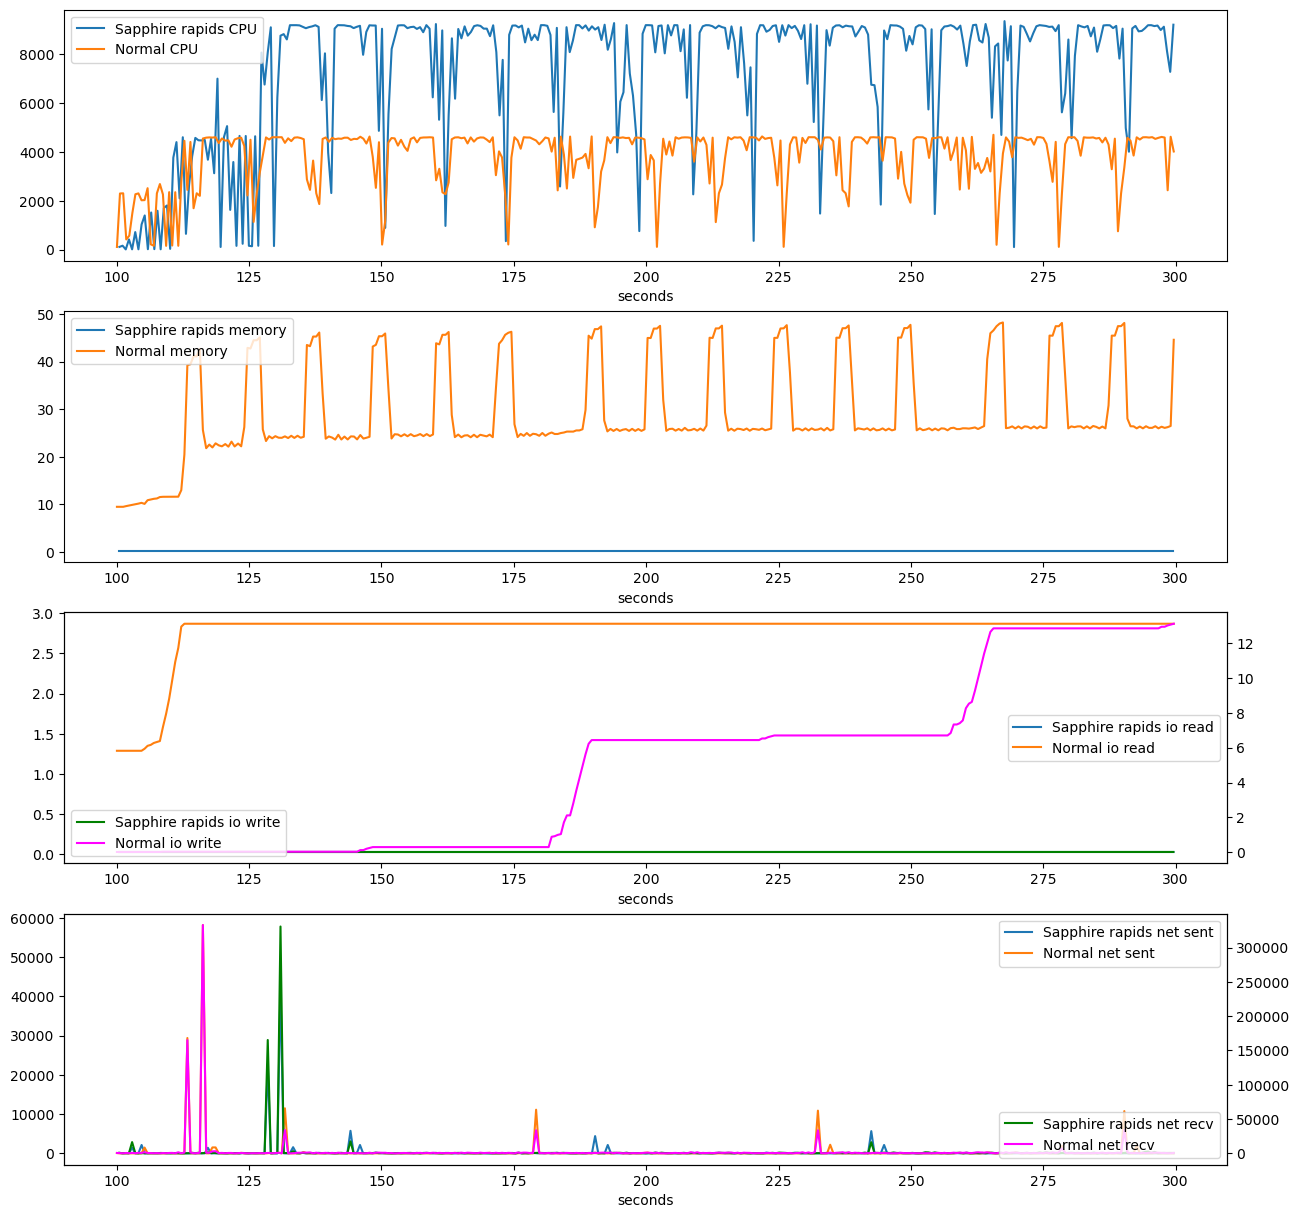

In [35]:
fig,ax = plt.subplots(4,1,figsize=(15,15))
start = pd.Timedelta('100 seconds')
end =  pd.Timedelta('300 seconds')
sr_df.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax[0])
io_df.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax[0])
lines, labels = ax[0].get_legend_handles_labels()
labels=['Sapphire rapids CPU','Normal CPU']
ax[0].legend(lines,labels)

sr_df.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax[1])
io_df.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax[1])
lines, labels = ax[1].get_legend_handles_labels()
labels=['Sapphire rapids memory','Normal memory']
ax[1].legend(lines,labels)

sr_df.loc[start:end].set_index('seconds')[['io_read_bytes']].plot(ax=ax[2])
io_df.loc[start:end].set_index('seconds')[['io_read_bytes']].plot(ax=ax[2])
lines, labels = ax[2].get_legend_handles_labels()
labels=['Sapphire rapids io read','Normal io read']
ax[2].legend(lines,labels)

ax3 = ax[2].twinx()
sr_df.loc[start:end].set_index('seconds')[['io_write_bytes']].plot(ax=ax3,color='green').legend(loc='lower right')
io_df.loc[start:end].set_index('seconds')[['io_write_bytes']].plot(ax=ax3,color='magenta').legend(loc='lower right')
lines, labels = ax3.get_legend_handles_labels()
labels=['Sapphire rapids io write','Normal io write']
ax3.legend(lines,labels,loc='lower left')

sr_df.loc[start:end].set_index('seconds')[['net_sent_bytes']].plot(ax=ax[3])
io_df.loc[start:end].set_index('seconds')[['net_sent_bytes']].plot(ax=ax[3])
lines, labels = ax[3].get_legend_handles_labels()
labels=['Sapphire rapids net sent','Normal net sent']
ax[3].legend(lines,labels)

ax4 = ax[3].twinx()
sr_df.loc[start:end].set_index('seconds')[['net_recv_bytes']].plot(ax=ax4,color='green').legend(loc='upper left')
io_df.loc[start:end].set_index('seconds')[['net_recv_bytes']].plot(ax=ax4,color='magenta').legend(loc='upper left')
lines, labels = ax4.get_legend_handles_labels()
labels=['Sapphire rapids net recv','Normal net recv']
ax4.legend(lines,labels,loc='lower right')

Overall sapphire rapids does save a minute or so for a 6-day run

In [62]:
io_timesteps

,0,1,2,3,timestep,5,6,seconds,8,marker,time
time_elapsed,,,,,,,,,,,
0 days 00:01:24.483000,Atm_Step:,Info:,Starting,timestep,0,at,time=,84.483,seconds,1.0,1970-01-01 00:01:24.483
0 days 00:01:32.678000,Atm_Step:,Info:,Starting,timestep,1,at,time=,92.678,seconds,1.0,1970-01-01 00:01:32.678
0 days 00:01:37.607000,Atm_Step:,Info:,Starting,timestep,2,at,time=,97.607,seconds,1.0,1970-01-01 00:01:37.607
0 days 00:01:38.908000,Atm_Step:,Info:,Starting,timestep,3,at,time=,98.908,seconds,1.0,1970-01-01 00:01:38.908
0 days 00:01:40.218000,Atm_Step:,Info:,Starting,timestep,4,at,time=,100.218,seconds,1.0,1970-01-01 00:01:40.218
...,...,...,...,...,...,...,...,...,...,...,...
0 days 00:31:59.076000,Atm_Step:,Info:,Starting,timestep,860,at,time=,1919.076,seconds,1.0,1970-01-01 00:31:59.076
0 days 00:32:00.368000,Atm_Step:,Info:,Starting,timestep,861,at,time=,1920.368,seconds,1.0,1970-01-01 00:32:00.368
0 days 00:32:01.645000,Atm_Step:,Info:,Starting,timestep,862,at,time=,1921.645,seconds,1.0,1970-01-01 00:32:01.645


In [65]:
sr_timesteps

,0,1,2,3,timestep,5,6,seconds,8,marker,time
time_elapsed,,,,,,,,,,,
0 days 00:01:30.618000,Atm_Step:,Info:,Starting,timestep,0,at,time=,90.618,seconds,1.0,1970-01-01 00:01:30.618
0 days 00:01:38.982000,Atm_Step:,Info:,Starting,timestep,1,at,time=,98.982,seconds,1.0,1970-01-01 00:01:38.982
0 days 00:01:44.818000,Atm_Step:,Info:,Starting,timestep,2,at,time=,104.818,seconds,1.0,1970-01-01 00:01:44.818
0 days 00:01:46.080000,Atm_Step:,Info:,Starting,timestep,3,at,time=,106.080,seconds,1.0,1970-01-01 00:01:46.080
0 days 00:01:47.364000,Atm_Step:,Info:,Starting,timestep,4,at,time=,107.364,seconds,1.0,1970-01-01 00:01:47.364
...,...,...,...,...,...,...,...,...,...,...,...
0 days 00:29:28.097000,Atm_Step:,Info:,Starting,timestep,860,at,time=,1768.097,seconds,1.0,1970-01-01 00:29:28.097
0 days 00:29:29.320000,Atm_Step:,Info:,Starting,timestep,861,at,time=,1769.320,seconds,1.0,1970-01-01 00:29:29.320
0 days 00:29:30.547000,Atm_Step:,Info:,Starting,timestep,862,at,time=,1770.547,seconds,1.0,1970-01-01 00:29:30.547


In [72]:
print (f'Sapphire rapids saves {io_timesteps.seconds.iloc[-1] - sr_timesteps.seconds.iloc[-1]:2f} seconds for a 6 day forecast')

Sapphire rapids saves 151.216000 seconds for a 6 day forecast


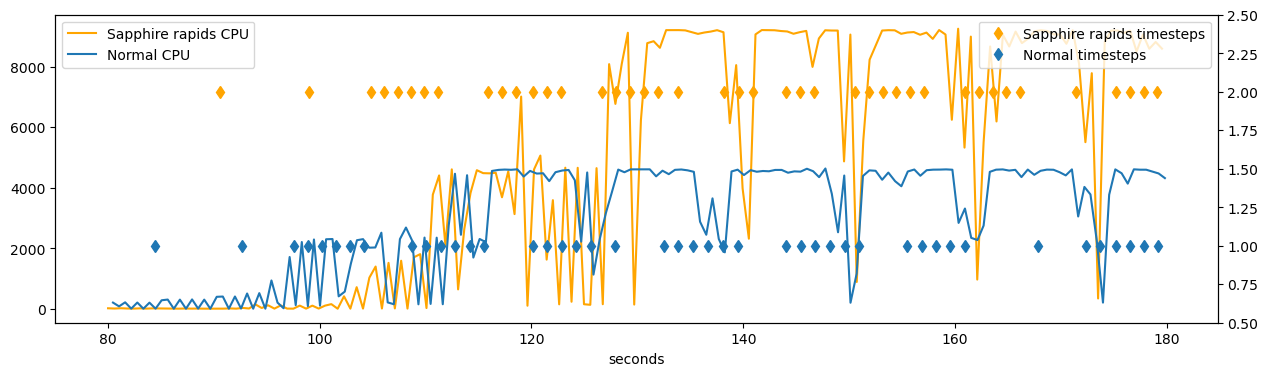

In [95]:
fig,ax = plt.subplots(1,1,figsize=(15,4))
start = pd.Timedelta('80 seconds')
end =  pd.Timedelta('180 seconds')
sr_df.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax,color='orange')
io_df.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax)
lines, labels = ax.get_legend_handles_labels()
labels=['Sapphire rapids CPU','Normal CPU']
ax.legend(lines,labels)


ax2 = ax.twinx()
(sr_timesteps.loc[start:end].set_index('seconds')[['marker']]+1).plot(ax=ax2,marker='d',linewidth=0,color='orange')
(io_timesteps.loc[start:end].set_index('seconds')[['marker']]).plot(ax=ax2,marker='d',linewidth=0)
ax2.set_ylim([0.5,2.5])
lines, labels = ax2.get_legend_handles_labels()
labels=['Sapphire rapids timesteps','Normal timesteps']
ax2.legend(lines,labels)

How much longer does the sapphire rapids task take to finish compared to the normal queue?

From the sapphire pe0 file.
```
Atm_Step: Info: Starting timestep      864 at time=  1773.017 seconds
...
Atm_Step: Info: timestep      864 took      7.926 seconds
...
um_shell: Info: End model run at time=  1824.588 seconds
```
And the default pe0 file.
```
********************
Atm_Step: Info: Starting timestep      864 at time=  1924.233 seconds
...
Atm_Step: Info: timestep      864 took     12.092 seconds
....
um_shell: Info: End model run at time=  2011.426 seconds
```

In [104]:
print (f'Sapphire rapids takes {1824.588 - 1773.017 - 7.926:.2f} seconds to finish after last iteration.')
print (f'Normal queue  takes {2011.426 - 1924.233  - 12.092:.2f} seconds to finish after last iteration.')

Sapphire rapids takes 43.64 seconds to finish after last iteration.
Normal queue  takes 75.10 seconds to finish after last iteration.


Note the different performance of the I/O servers between the normal and normalsr queue. The normal queue results (on the right) has 10 times the bandwidth for `BUFFIN` operations!
<img src="images/xxdiff_sr.png">

Let's plot the performance of both runs from the last timestep

In [132]:
sr_df['last_time'] = sr_df['seconds'] - 1773.017 
io_df['last_time'] = io_df['seconds'] - 1924.233

In [145]:
sr_df.last_time.iloc[-157]

np.float64(0.14400001299986798)

In [144]:
io_df.last_time.iloc[-218]

np.float64(0.4029999179999777)

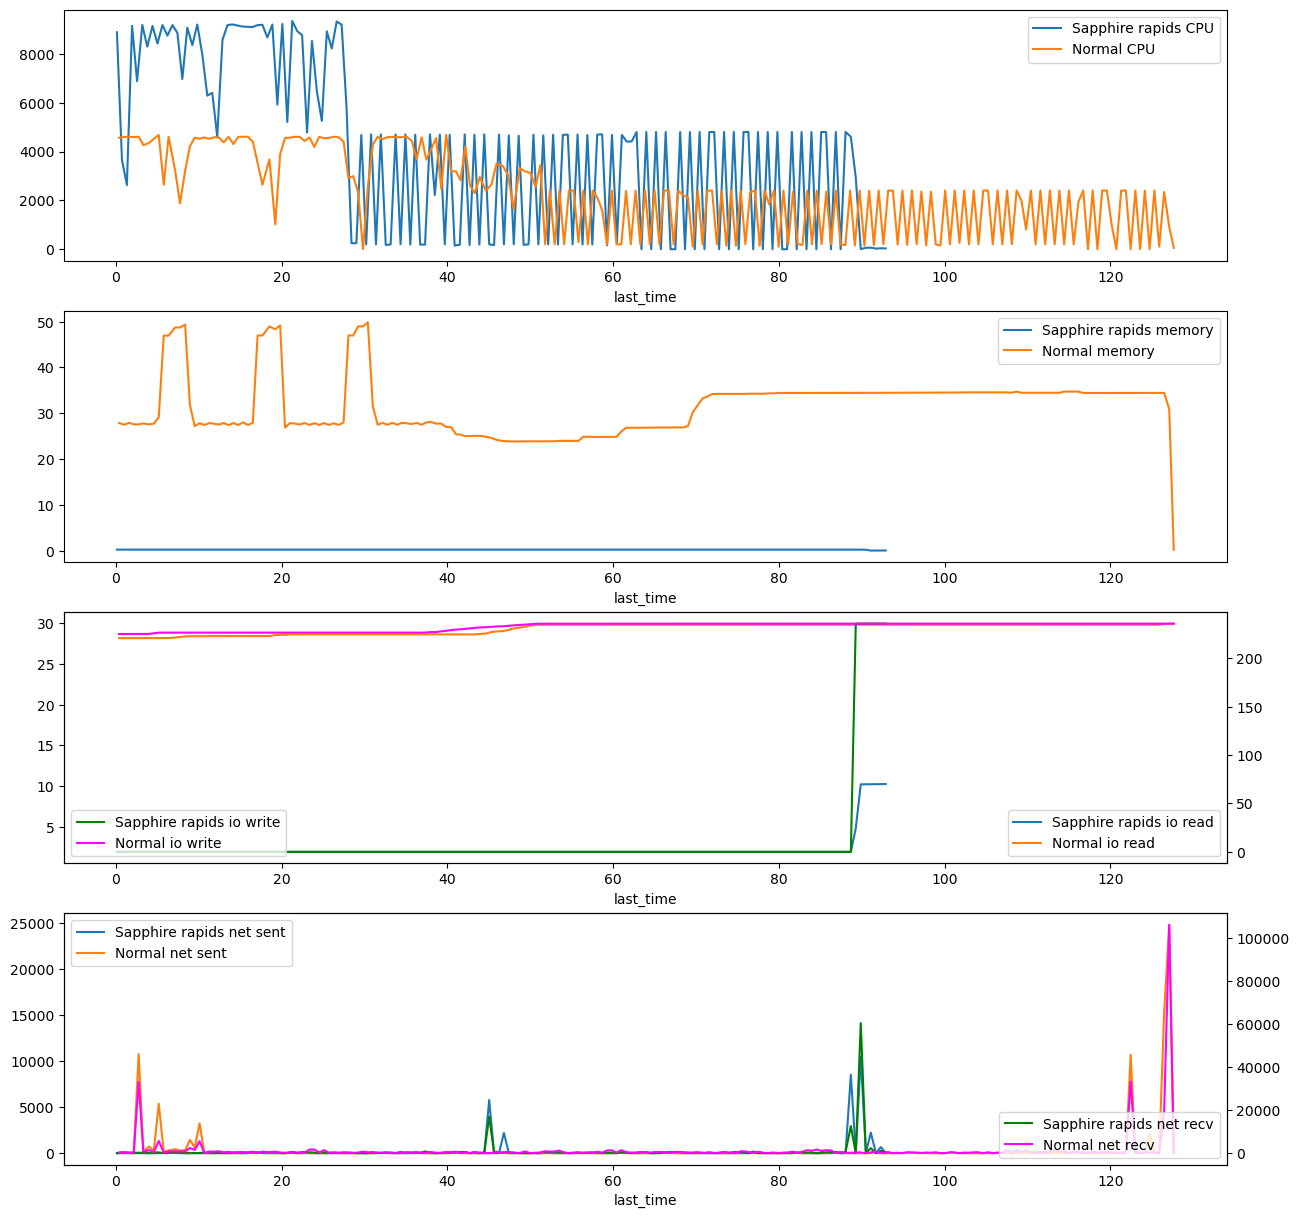

In [150]:
fig,ax = plt.subplots(4,1,figsize=(15,15))
sr_ix=157
io_ix=218
sr_df.iloc[-sr_ix:].set_index('last_time')[['system_cpu_efficiency']].plot(ax=ax[0])
io_df.iloc[-io_ix:].set_index('last_time')[['system_cpu_efficiency']].plot(ax=ax[0])
lines, labels = ax[0].get_legend_handles_labels()
labels=['Sapphire rapids CPU','Normal CPU']
ax[0].legend(lines,labels)

sr_df.iloc[-sr_ix:].set_index('last_time')[['rss_bytes_sum']].plot(ax=ax[1])
io_df.iloc[-io_ix:].set_index('last_time')[['rss_bytes_sum']].plot(ax=ax[1])
lines, labels = ax[1].get_legend_handles_labels()
labels=['Sapphire rapids memory','Normal memory']
ax[1].legend(lines,labels)

sr_df.iloc[-sr_ix:].set_index('last_time')[['io_read_bytes']].plot(ax=ax[2])
io_df.iloc[-io_ix:].set_index('last_time')[['io_read_bytes']].plot(ax=ax[2])
lines, labels = ax[2].get_legend_handles_labels()
labels=['Sapphire rapids io read','Normal io read']
ax[2].legend(lines,labels)

ax3 = ax[2].twinx()
sr_df.iloc[-sr_ix:].set_index('last_time')[['io_write_bytes']].plot(ax=ax3,color='green').legend(loc='lower right')
io_df.iloc[-io_ix:].set_index('last_time')[['io_write_bytes']].plot(ax=ax3,color='magenta').legend(loc='lower right')
lines, labels = ax3.get_legend_handles_labels()
labels=['Sapphire rapids io write','Normal io write']
ax3.legend(lines,labels,loc='lower left')

sr_df.iloc[-sr_ix:].set_index('last_time')[['net_sent_bytes']].plot(ax=ax[3])
io_df.iloc[-io_ix:].set_index('last_time')[['net_sent_bytes']].plot(ax=ax[3])
lines, labels = ax[3].get_legend_handles_labels()
labels=['Sapphire rapids net sent','Normal net sent']
ax[3].legend(lines,labels)

ax4 = ax[3].twinx()
sr_df.iloc[-sr_ix:].set_index('last_time')[['net_recv_bytes']].plot(ax=ax4,color='green').legend(loc='upper left')
io_df.iloc[-io_ix:].set_index('last_time')[['net_recv_bytes']].plot(ax=ax4,color='magenta').legend(loc='upper left')
lines, labels = ax4.get_legend_handles_labels()
labels=['Sapphire rapids net recv','Normal net recv']
ax4.legend(lines,labels,loc='lower right')